# 3.1 Data Overview

In [ ]:
import pandas as pd
df = pd.read_csv("/content/HousePricesDataset.csv")

In [ ]:
df.dtypes

,0
Id,int64
MSZoning,object
LotFrontage,float64
LotArea,int64
Street,object
Alley,object
LotShape,object
Neighborhood,object
BldgType,object
HouseStyle,object


In [ ]:
# Shape
print(f"Shape of data: {df.shape}\n")

cat_col = df.select_dtypes(include='object').columns
print(f"Number of categorical columns: {len(list(cat_col))}\n")

num_col = df.select_dtypes(include='object').columns
print(f"Number of numerical columns: {df.shape[1] - len(list(num_col))}\n")

Shape of data: (1300, 31)

Number of categorical columns: 10

Number of numerical columns: 21



In [ ]:
# View the first rows of data
df.head()

,Id,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,Neighborhood,BldgType,HouseStyle,...,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,GarageType,GarageCars,GarageArea,WoodDeckSF,PoolArea,SalePrice
0,1,RL,65.0,8450,Pave,NaN,Reg,CollgCr,1Fam,2Story,...,1,3,1,8,Attchd,2,548,0,0,208500
1,2,RL,80.0,9600,Pave,NaN,Reg,Veenker,1Fam,1Story,...,0,3,1,6,Attchd,2,460,298,0,181500
2,3,RL,68.0,11250,Pave,NaN,IR1,CollgCr,1Fam,2Story,...,1,3,1,6,Attchd,2,608,0,0,223500
3,4,RL,60.0,9550,Pave,NaN,IR1,Crawfor,1Fam,2Story,...,0,3,1,7,Detchd,3,642,0,0,140000
4,5,RL,84.0,14260,Pave,NaN,IR1,NoRidge,1Fam,2Story,...,1,4,1,9,Attchd,3,836,192,0,250000


# 3.2 Data exploration

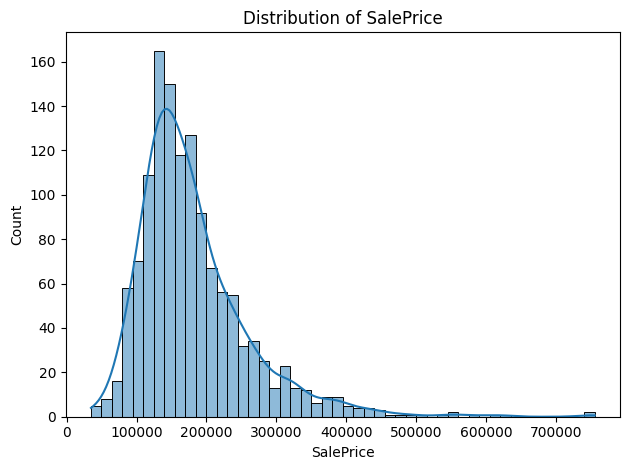

In [ ]:
# Numerical distributions
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['SalePrice'],kde=True)
plt.title(f"Distribution of SalePrice")
plt.tight_layout()
plt.show()

In [ ]:
# Summary statistics (Numerical)
df[df.select_dtypes(exclude='object').columns].describe()

,Id,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,1stFlrSF,2ndFlrSF,...,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,GarageCars,GarageArea,WoodDeckSF,PoolArea,SalePrice
count,1300.000000,1071.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,...,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000,1300.000000
mean,650.500000,70.198880,10573.323077,6.102308,5.573846,1971.293846,1984.676923,1058.169231,1161.307692,344.632308,...,1.559231,0.384615,2.861538,1.046923,6.506923,1.759231,472.063846,94.936154,2.131538,180983.514615
std,375.421985,24.622546,10388.805901,1.378766,1.118778,29.934696,20.605879,442.752892,387.452417,435.349222,...,0.553830,0.502260,0.817946,0.222204,1.622337,0.740160,212.708520,123.622310,34.502318,80096.642018
min,1.000000,21.000000,1300.000000,1.000000,1.000000,1875.000000,1950.000000,0.000000,334.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,34900.000000
25%,325.750000,59.000000,7590.000000,5.000000,5.000000,1954.000000,1966.000000,796.000000,882.000000,0.000000,...,1.000000,0.000000,2.000000,1.000000,5.000000,1.000000,334.500000,0.000000,0.000000,130000.000000
50%,650.500000,70.000000,9476.500000,6.000000,5.000000,1972.000000,1993.000000,998.500000,1087.000000,0.000000,...,2.000000,0.000000,3.000000,1.000000,6.000000,2.000000,478.000000,0.000000,0.000000,163000.000000
75%,975.250000,80.000000,11616.000000,7.000000,6.000000,2000.000000,2004.000000,1298.250000,1384.500000,728.000000,...,2.000000,1.000000,3.000000,1.000000,7.000000,2.000000,576.000000,168.000000,0.000000,213310.000000
max,1300.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,6110.000000,4692.000000,2065.000000,...,3.000000,2.000000,8.000000,3.000000,14.000000,4.000000,1418.000000,857.000000,648.000000,755000.000000


In [ ]:
# Summary statistics (Categorical)
df[df.select_dtypes(include='object').columns].describe(include='all')

,MSZoning,Street,Alley,LotShape,Neighborhood,BldgType,HouseStyle,RoofStyle,Electrical,GarageType
count,1300,1300,77,1300,1300,1300,1300,1300,1300,1228
unique,5,2,2,4,25,5,8,6,5,6
top,RL,Pave,Grvl,Reg,NAmes,1Fam,1Story,Gable,SBrkr,Attchd
freq,1028,1294,42,818,202,1085,646,1012,1184,777


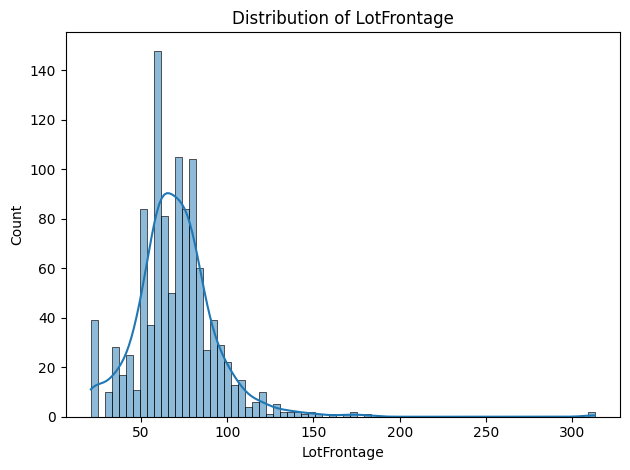

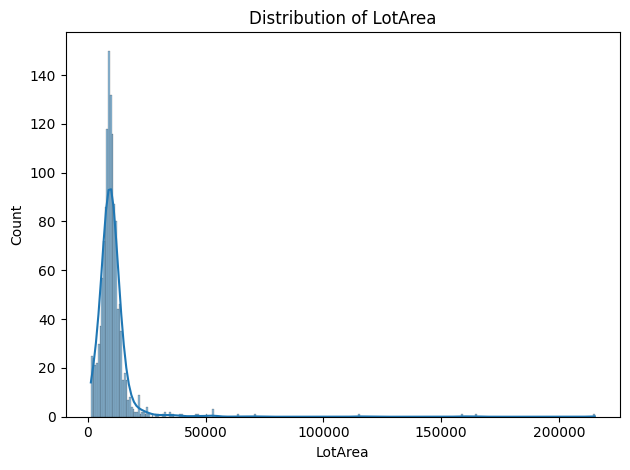

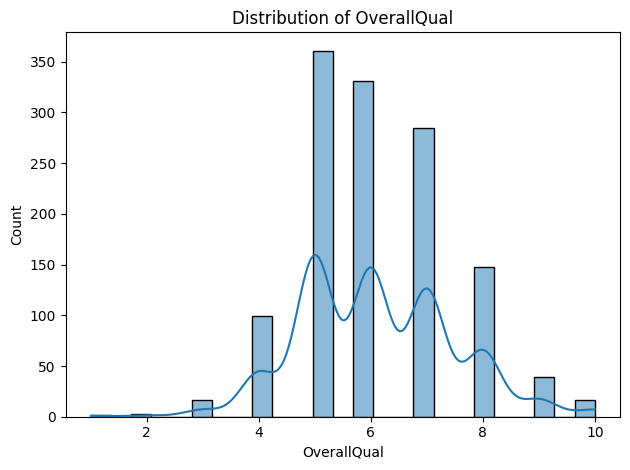

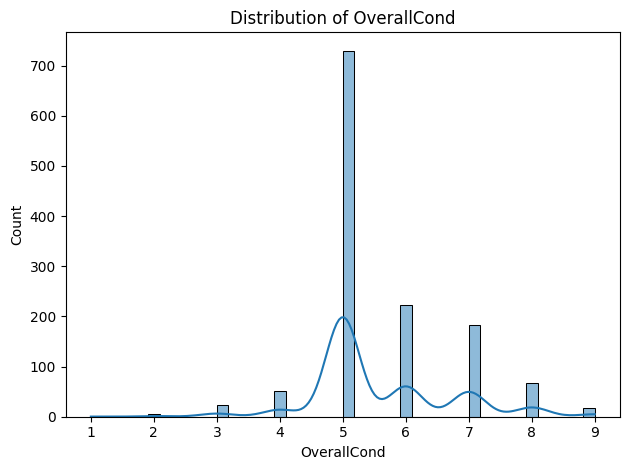

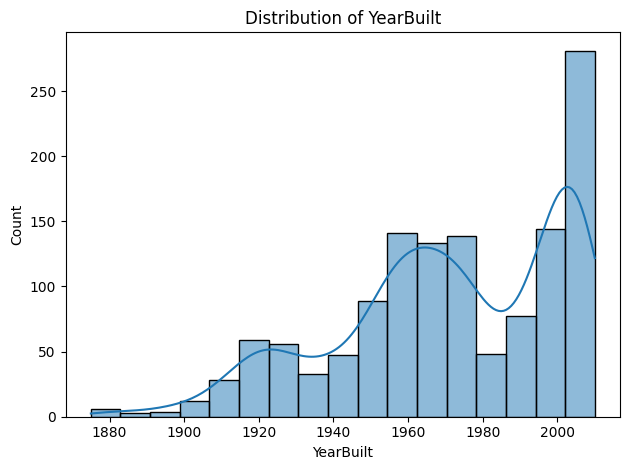

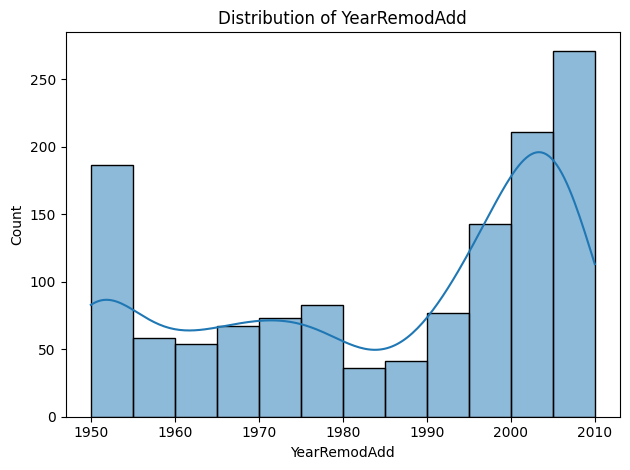

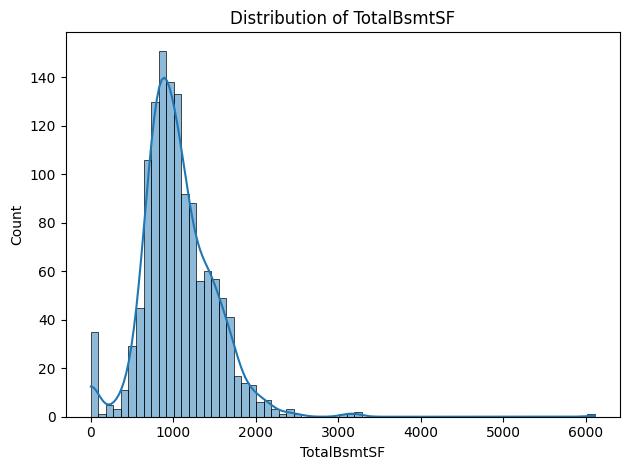

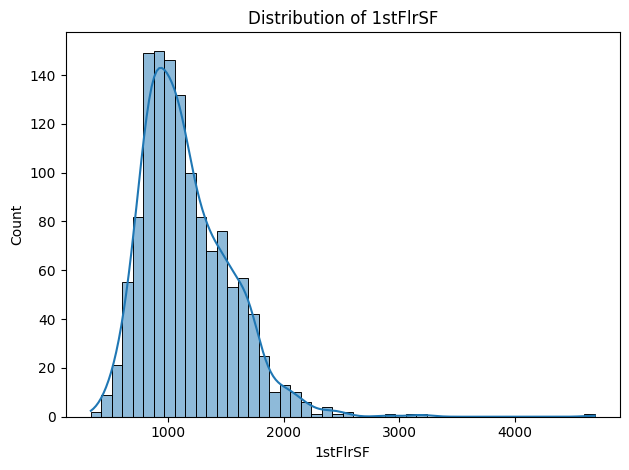

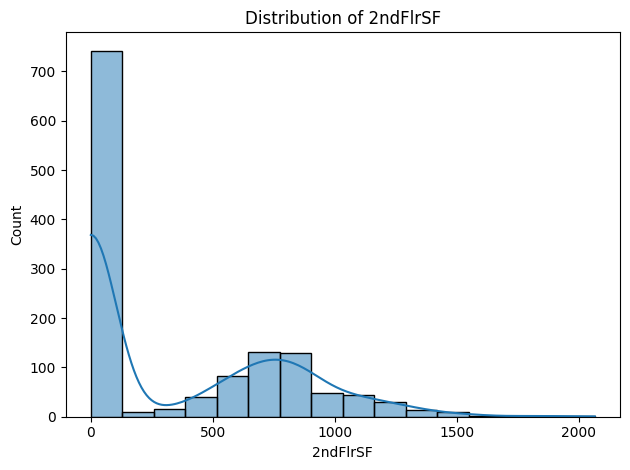

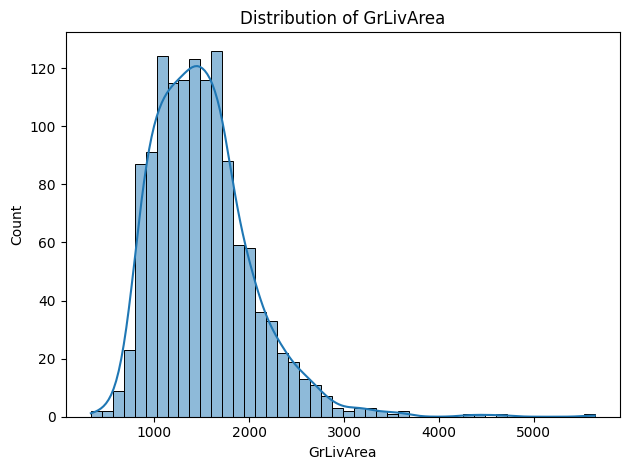

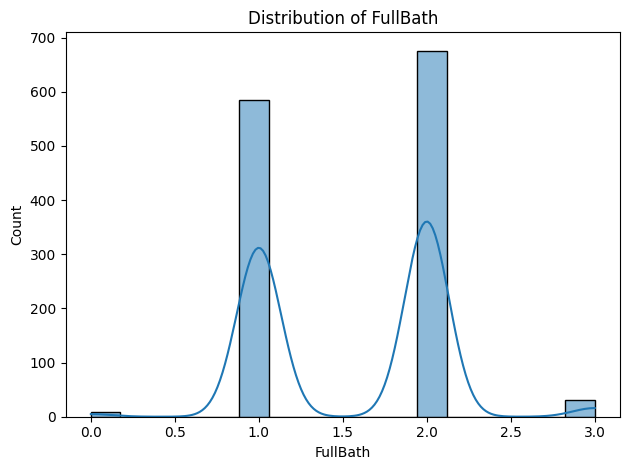

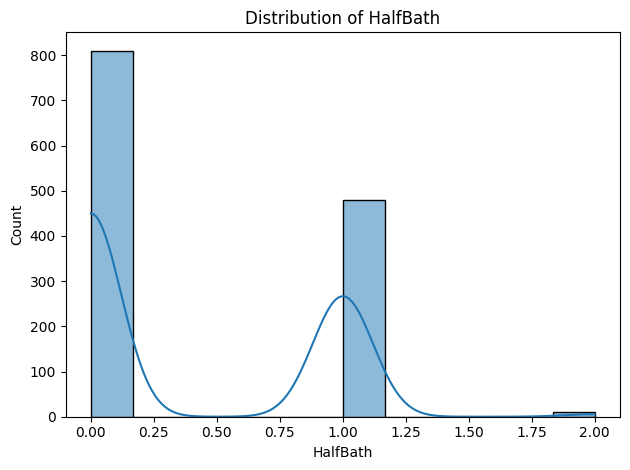

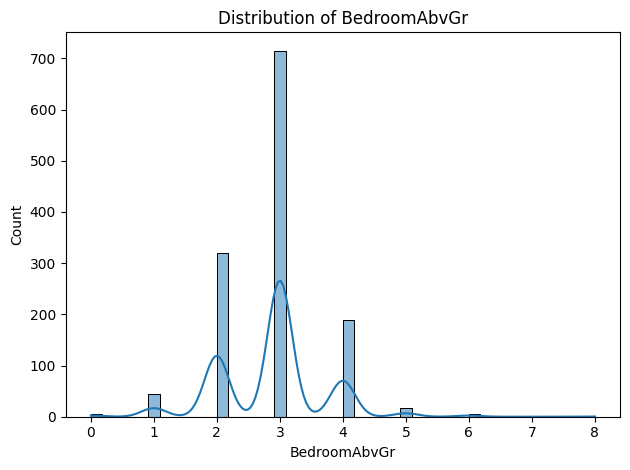

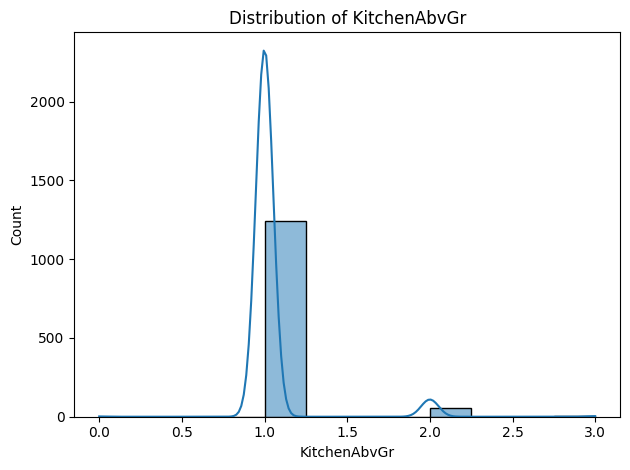

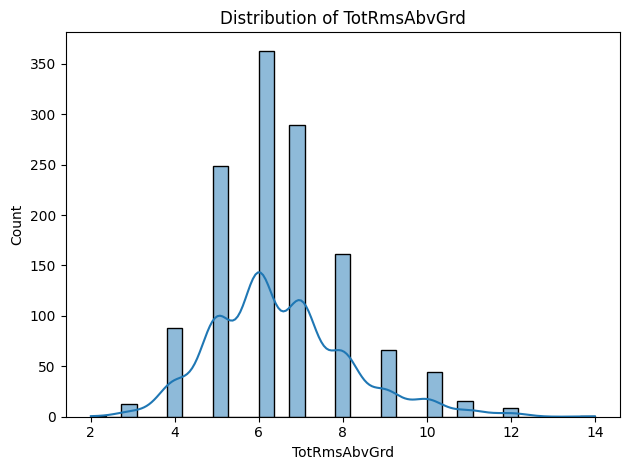

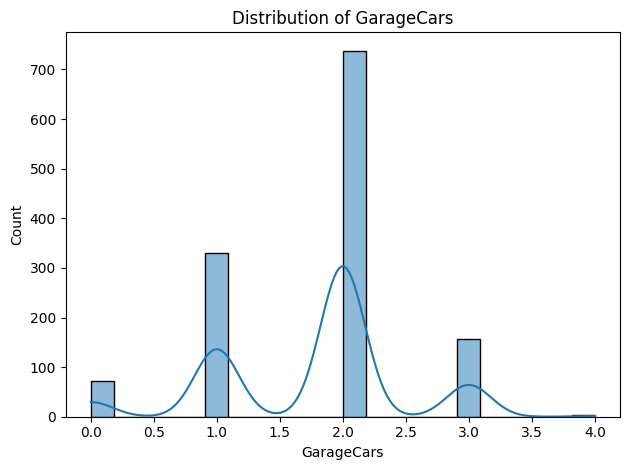

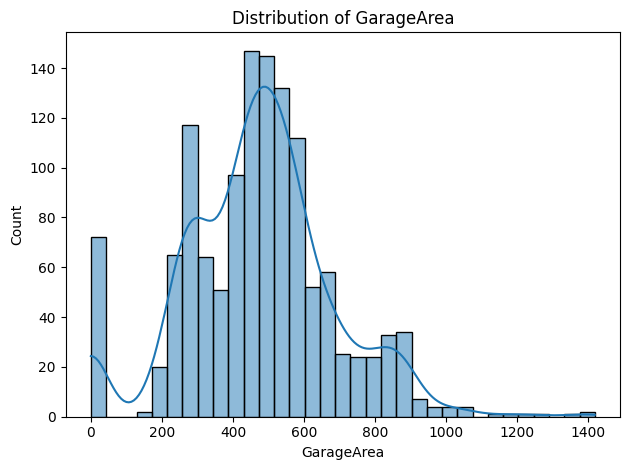

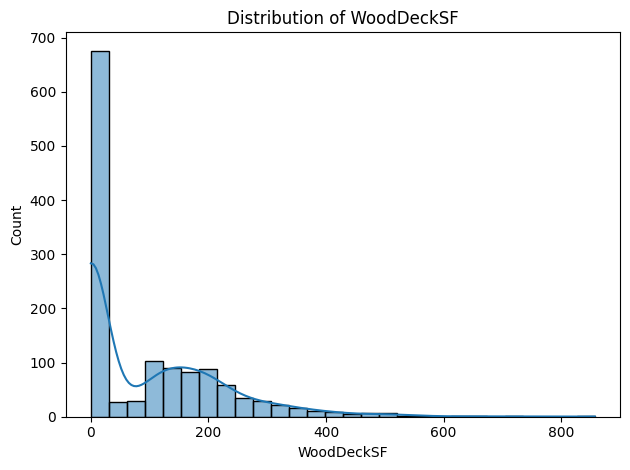

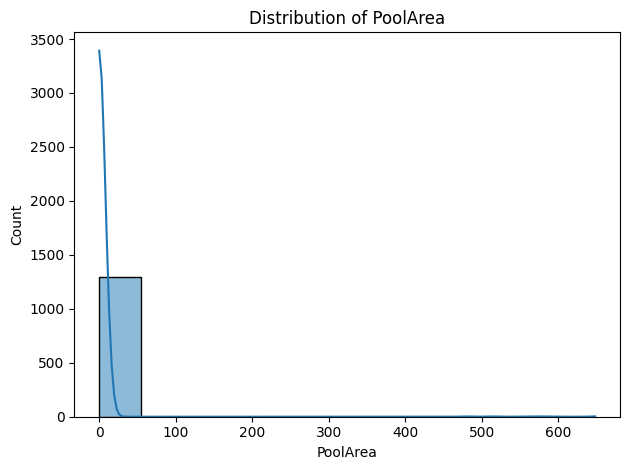

In [ ]:
# Numerical distributions
import seaborn as sns
import matplotlib.pyplot as plt

num_col = df.select_dtypes(exclude='object').columns.drop(['Id','SalePrice'])

for col_name in num_col:
  sns.histplot(df[col_name],kde=True)
  plt.title(f"Distribution of {col_name}")
  plt.tight_layout()
  plt.show()

In [ ]:
# Inspect categorical distributions
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select categorical column names
cat_col = df.select_dtypes(include='object').columns

for col_name in cat_col:
  print(f"Analysis for categorical column: {col_name}")
  current_column = df[col_name]

  # 1. Basic Frequency Count
  print(f"Counts:\n{current_column.value_counts()}")

  # 2. Relative Frequency (Percentage)
  print(f"\nPercentages:\n{current_column.value_counts(normalize=True) * 100}")

  # 3. Number of unique values
  print(f"\nNumber of unique values: {current_column.nunique()}")
  print("------------------------------------------------------")

Analysis for categorical column: MSZoning
Counts:
MSZoning
RL         1028
RM          189
FV           58
RH           15
C (all)      10
Name: count, dtype: int64

Percentages:
MSZoning
RL         79.076923
RM         14.538462
FV          4.461538
RH          1.153846
C (all)     0.769231
Name: proportion, dtype: float64

Number of unique values: 5
------------------------------------------------------
Analysis for categorical column: Street
Counts:
Street
Pave    1294
Grvl       6
Name: count, dtype: int64

Percentages:
Street
Pave    99.538462
Grvl     0.461538
Name: proportion, dtype: float64

Number of unique values: 2
------------------------------------------------------
Analysis for categorical column: Alley
Counts:
Alley
Grvl    42
Pave    35
Name: count, dtype: int64

Percentages:
Alley
Grvl    54.545455
Pave    45.454545
Name: proportion, dtype: float64

Number of unique values: 2
------------------------------------------------------
Analysis for categorical column: LotSh

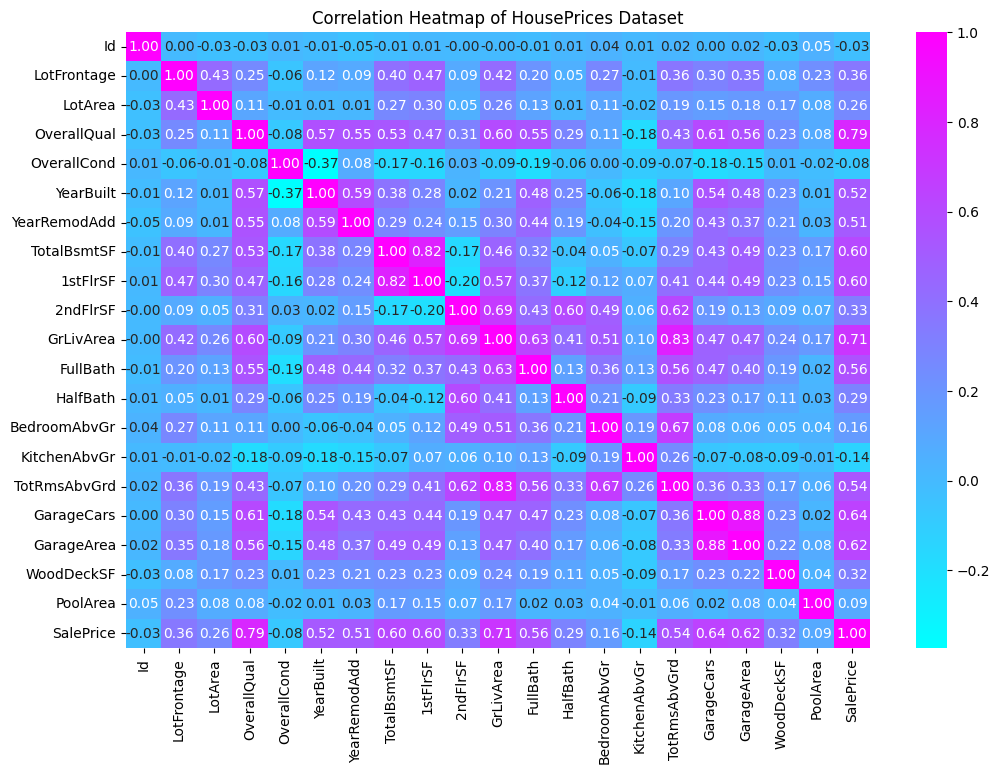

In [ ]:
# Pearson correlation heatmap
num_data = df.select_dtypes(include=['int64','float64'])
plt.figure(figsize=(12,8))
heatmap = sns.heatmap(num_data.corr(), annot=True, fmt=".2f", cmap="cool")
plt.title("Correlation Heatmap of HousePrices Dataset")
plt.show()

# # Convert into sheet
# numeric_df = df.select_dtypes(include=['float64', 'int64'])
# correlation_matrix = numeric_df.corr()
# correlation_matrix.to_excel('correlation_matrix.xlsx', sheet_name='Correlation_Matrix')
# print("Correlation matrix has been written to 'correlation_matrix.xlsx'")

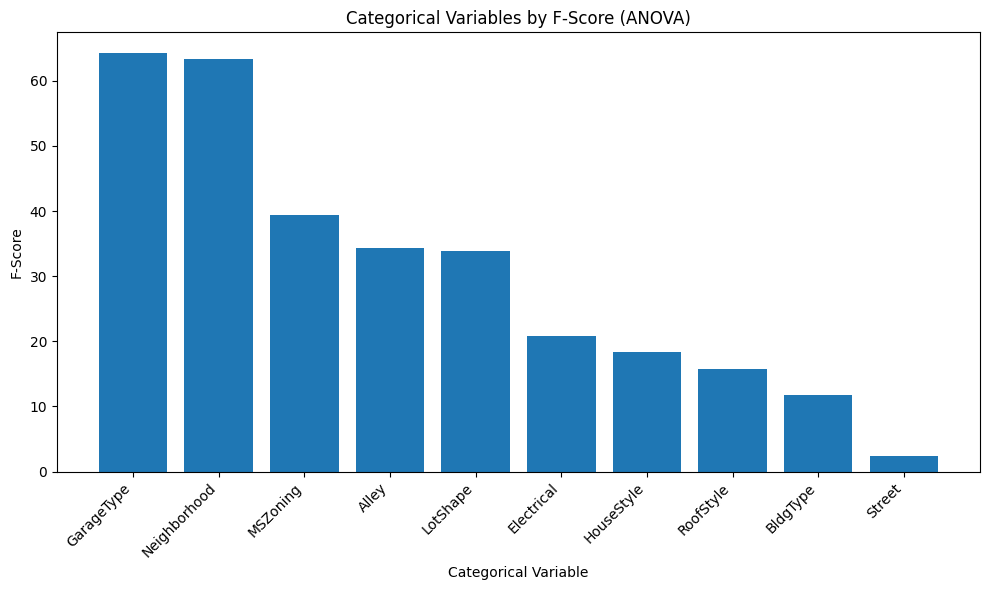

,Variable,F-Score,P-Value
9,GarageType,64.223073,1.340549e-59
4,Neighborhood,63.396054,8.642366e-198
0,MSZoning,39.402364,3.598279e-31
2,Alley,34.257888,1.191332e-07
3,LotShape,33.860564,4.539774e-21
8,Electrical,20.811936,1.212005e-16
6,HouseStyle,18.421998,1.687903e-23
7,RoofStyle,15.760596,4.342528e-15
5,BldgType,11.799935,2.037506e-09
1,Street,2.426702,1.195274e-01


In [ ]:
# One-way ANOVA for categorical features
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

categorical_cols = df.select_dtypes(include=['object']).columns
target_col = 'SalePrice'

results = []

for col in categorical_cols:
    price_groups = []
    unique_categories = df[col].unique()

    for category in unique_categories:
      # If missing
        if pd.isna(category):
            continue

        mask = (df[col] == category)

        prices = df[mask][target_col]

        clean_prices = prices.dropna()

        price_groups.append(clean_prices)

    if len(price_groups) >= 2:
        f_score, p_value = stats.f_oneway(*price_groups)

        results.append({
            'Variable': col,
            'F-Score': f_score,
            'P-Value': p_value
        })

results_df = pd.DataFrame(results)

sorted_results = results_df.sort_values(by='F-Score', ascending=False)

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(sorted_results['Variable'], sorted_results['F-Score'])
plt.xlabel('Categorical Variable')
plt.ylabel('F-Score')
plt.title('Categorical Variables by F-Score (ANOVA)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

sorted_results

# 3.3 Data cleaning

In [ ]:
print(f"Number of duplicated: {df.duplicated().sum()}")

Number of duplicated: 0


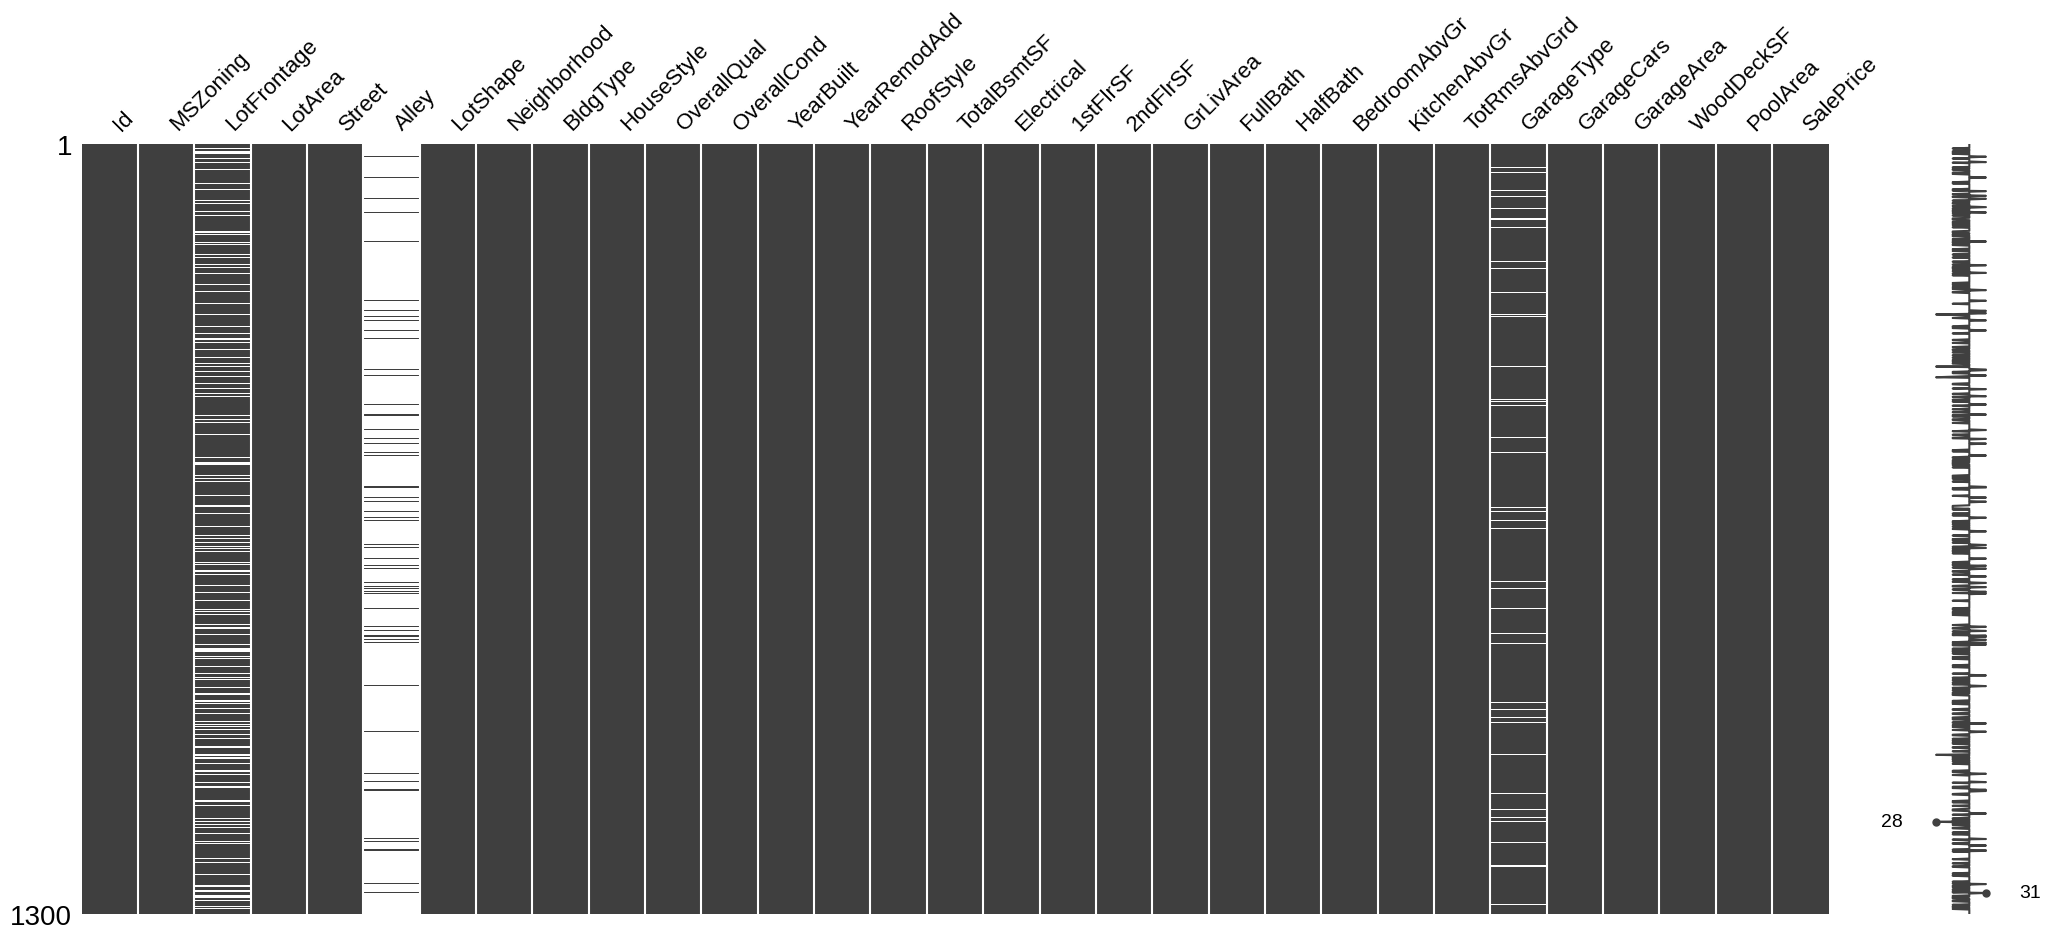

<Figure size 1000x800 with 0 Axes>

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt

msno.matrix(df)
plt.style.use("seaborn-v0_8")
plt.figure(figsize = (10,8))
plt.tight_layout()
plt.show()

In [ ]:
missing_data = df.isna().sum()
print(f"Total missing values: {missing_data[missing_data>0]}, \n percetange: {missing_data[missing_data>0]/len(df)*100} \n")
print(f"Info: {[df.info()]}, \n")

Total missing values: LotFrontage     229
Alley          1223
GarageType       72
dtype: int64, 
 percetange: LotFrontage    17.615385
Alley          94.076923
GarageType      5.538462
dtype: float64 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1300 entries, 0 to 1299
Data columns (total 31 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            1300 non-null   int64  
 1   MSZoning      1300 non-null   object 
 2   LotFrontage   1071 non-null   float64
 3   LotArea       1300 non-null   int64  
 4   Street        1300 non-null   object 
 5   Alley         77 non-null     object 
 6   LotShape      1300 non-null   object 
 7   Neighborhood  1300 non-null   object 
 8   BldgType      1300 non-null   object 
 9   HouseStyle    1300 non-null   object 
 10  OverallQual   1300 non-null   int64  
 11  OverallCond   1300 non-null   int64  
 12  YearBuilt     1300 non-null   int64  
 13  YearRemodAdd  1300 non-null   int64  
 14

In [ ]:
# Imputing Alley and Garage Type
null_cat = ['Alley', 'GarageType']

for cat in null_cat:
  df[cat] = df[cat].fillna('None')
  print(f"Missing {cat} after imputation: {df[cat].isna().sum()}")
  print(f"{df[cat][:5]}\n")

Missing Alley after imputation: 0
0    None
1    None
2    None
3    None
4    None
Name: Alley, dtype: object

Missing GarageType after imputation: 0
0    Attchd
1    Attchd
2    Attchd
3    Detchd
4    Attchd
Name: GarageType, dtype: object



In [ ]:
# Group-wise imputing LotFrontage

neighborhood_median = df.groupby('Neighborhood')['LotFrontage'].transform('median')
df['LotFrontage'] = df['LotFrontage'].fillna(neighborhood_median)

# If the neighborhood has no records
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())
print(f"Missing LotFrontage after median imputation: {df['LotFrontage'].isna().sum()}")
print(f"{df['LotFrontage'][:10]}")

Missing LotFrontage after median imputation: 0
0    65.0
1    80.0
2    68.0
3    60.0
4    84.0
5    85.0
6    75.0
7    80.0
8    51.0
9    50.0
Name: LotFrontage, dtype: float64


# 3.4 Data transformation

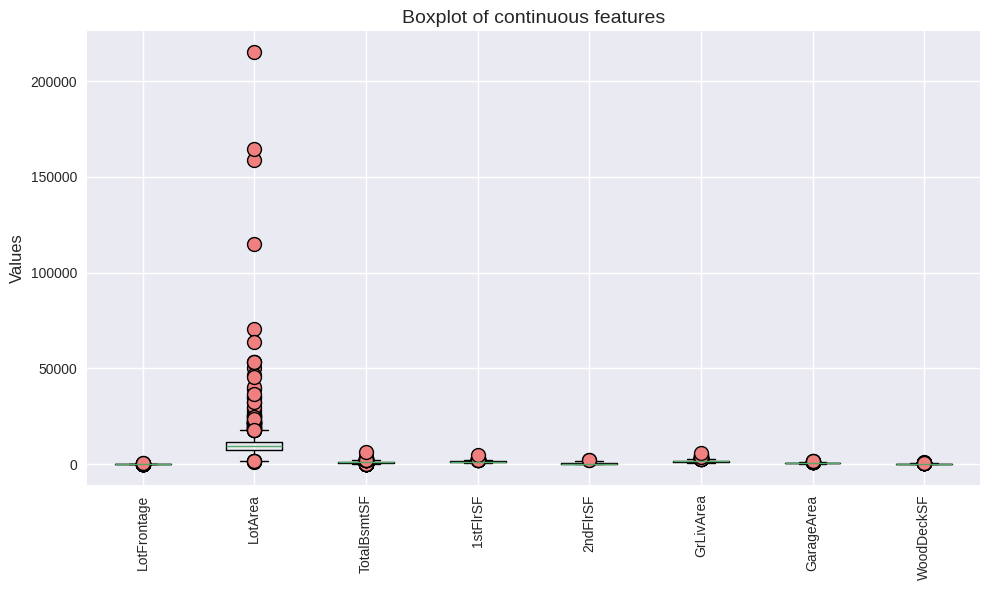

,0
LotFrontage,85
LotArea,66
TotalBsmtSF,58
1stFlrSF,18
2ndFlrSF,2
GrLivArea,28
GarageArea,19
WoodDeckSF,27


In [ ]:
# Box plot
plt.figure(figsize=(10,6))
continuous_variables = ['LotFrontage','LotArea','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','GarageArea','WoodDeckSF']
flierprops = dict(marker='o', markerfacecolor='lightcoral', markersize=10)
plt.boxplot(df[continuous_variables].values, flierprops=flierprops)
plt.title('Boxplot of continuous features', fontsize= 14)
plt.ylabel('Values', fontsize= 12)
plt.xticks(range(1, len(continuous_variables) + 1), continuous_variables, rotation=90)
plt.tight_layout()
plt.show()

# Counting
Q1 = df[continuous_variables].quantile(0.25)
Q3 = df[continuous_variables].quantile(0.75)
IQR = Q3 - Q1
outliers = (df[continuous_variables] < (Q1 - 1.5 * IQR)) | (df[continuous_variables] > (Q3 + 1.5 *IQR))
outliers.sum()

In [ ]:
# Clamp transformation
import numpy as np
continuous_variables = ['LotFrontage','LotArea','TotalBsmtSF','1stFlrSF','2ndFlrSF','GrLivArea','GarageArea','WoodDeckSF']
lower_bounds = Q1 - 1.5 * IQR
upper_bounds = Q3 + 1.5 * IQR

for col in continuous_variables:
    df[col] = df[col].clip(lower=lower_bounds[col], upper=upper_bounds[col])

In [ ]:
# Encoding
import numpy as np
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()

# Electrical
label_encoder.fit(df['Electrical'])
label_encoder.classes_ = np.array(['Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'])
df['Electrical'] = label_encoder.transform(df['Electrical'])

# LotShape
label_encoder.fit(df['LotShape'])
label_encoder.classes_ = np.array(['Reg', 'IR1', 'IR2', 'IR3'])
df['LotShape'] = label_encoder.transform(df['LotShape'])

df[['Electrical','LotShape']].head(5)

,Electrical,LotShape
0,4,0
1,4,0
2,4,1
3,4,1
4,4,1


In [ ]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

nominal_features = ['MSZoning', 'Neighborhood', 'BldgType', 'RoofStyle', 'GarageType', 'Alley', 'HouseStyle','Street']

encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_data = encoder.fit_transform(df[nominal_features])
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(nominal_features)
)
df = pd.concat([df, encoded_df], axis=1)
df = df.drop(columns=nominal_features)
df.head()

,Id,LotFrontage,LotArea,LotShape,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,Electrical,...,Alley_None,Alley_Pave,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,Street_Pave
0,1,65.0,8450,0,7,5,2003,2003,856.0,4,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
1,2,80.0,9600,0,6,8,1976,1976,1262.0,4,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,3,68.0,11250,1,7,5,2001,2002,920.0,4,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,4,60.0,9550,1,7,5,1915,1970,756.0,4,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,5,84.0,14260,1,8,5,2000,2000,1145.0,4,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
# Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

numerical_columns = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'PoolArea','Electrical','LotShape']

df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
df[numerical_columns].head()

,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,TotalBsmtSF,1stFlrSF,2ndFlrSF,GrLivArea,...,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,GarageCars,GarageArea,WoodDeckSF,PoolArea,Electrical,LotShape
0,-0.253628,-0.336339,0.651334,-0.51312,1.059585,0.889558,-0.488024,-0.828883,1.173236,0.443758,...,1.225703,0.169345,-0.211252,0.920679,0.325419,0.381814,-0.799545,-0.061803,0.285223,-0.709511
1,0.578709,-0.013593,-0.074231,2.16941,0.157275,-0.421252,0.530658,0.296084,-0.792916,-0.497976,...,-0.766064,0.169345,-0.211252,-0.312585,0.325419,-0.046718,1.767129,-0.061803,0.285223,-0.709511
2,-0.087161,0.449477,0.651334,-0.51312,0.992747,0.841010,-0.327444,-0.651548,1.200863,0.603516,...,1.225703,0.169345,-0.211252,-0.312585,0.325419,0.673994,-0.799545,-0.061803,0.285223,1.011318
3,-0.531074,-0.027626,0.651334,-0.51312,-1.881279,-0.712543,-0.738931,-0.537943,0.947612,0.458473,...,-0.766064,0.169345,-0.211252,0.304047,1.676999,0.839564,-0.799545,-0.061803,0.285223,1.011318
4,0.800666,1.294229,1.376900,-0.51312,0.959328,0.743913,0.237097,-0.028106,1.631391,1.469575,...,1.225703,1.392390,-0.211252,1.537311,1.676999,1.784281,0.854151,-0.061803,0.285223,1.011318


# 3.5 Feature selection

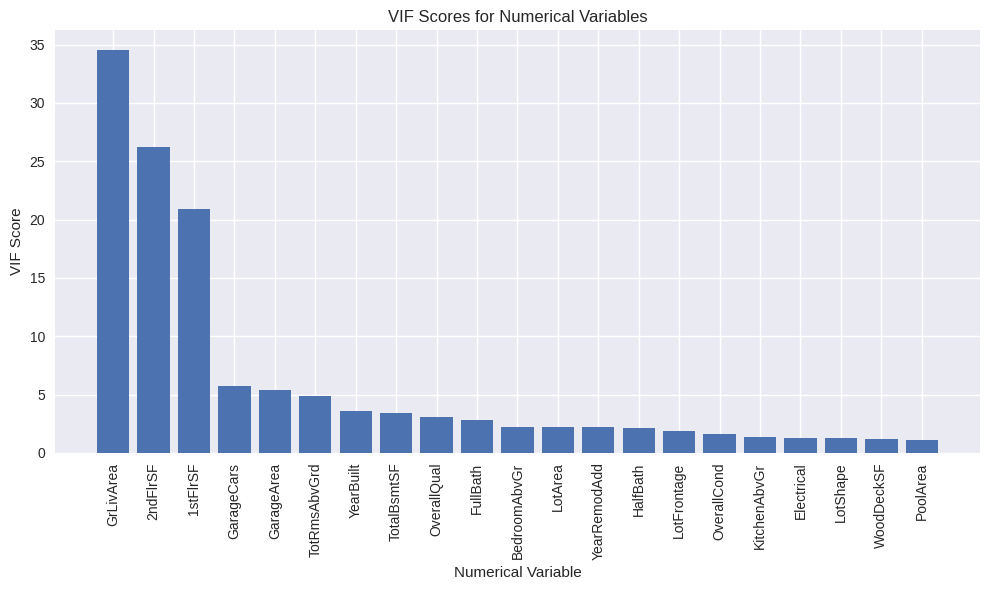

Variance Inflation Factors:
  GrLivArea: 34.492
  2ndFlrSF: 26.231
  1stFlrSF: 20.919
  GarageCars: 5.768
  GarageArea: 5.411
  TotRmsAbvGrd: 4.892
  YearBuilt: 3.624
  TotalBsmtSF: 3.457
  OverallQual: 3.095
  FullBath: 2.816
  BedroomAbvGr: 2.237
  LotArea: 2.213
  YearRemodAdd: 2.186
  HalfBath: 2.157
  LotFrontage: 1.873
  OverallCond: 1.573
  KitchenAbvGr: 1.349
  Electrical: 1.247
  LotShape: 1.235
  WoodDeckSF: 1.160
  PoolArea: 1.069


In [ ]:
# Multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
import matplotlib.pyplot as plt

numerical_columns = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt',
       'YearRemodAdd', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'GrLivArea',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'GarageCars', 'GarageArea', 'WoodDeckSF', 'PoolArea','Electrical','LotShape']


x_train = df[numerical_columns]
vif_scores = [variance_inflation_factor(x_train.values, i) for i in range(x_train.shape[1])]

order = np.argsort(vif_scores)[::-1]
sorted_cols = x_train.columns[order]
sorted_vif = np.array(vif_scores)[order]

# Plotting
plt.figure(figsize=(10, 6))
plt.bar(sorted_cols, sorted_vif)
plt.xlabel('Numerical Variable')
plt.ylabel('VIF Score')
plt.title('VIF Scores for Numerical Variables')
plt.xticks(rotation=90, ha="center")
plt.tight_layout()
plt.show()

# view VIF for each numerical variable (highest first)
print("Variance Inflation Factors:")
for name, vif in zip(sorted_cols, sorted_vif):
    print(f"  {name}: {vif:.3f}")

In [ ]:
# Dropping
df = df.drop(columns=['GarageArea','1stFlrSF','2ndFlrSF','TotRmsAbvGrd'])

In [ ]:
df.columns

Index(['Id', 'LotFrontage', 'LotArea', 'LotShape', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'TotalBsmtSF', 'Electrical',
       'GrLivArea', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr',
       'GarageCars', 'WoodDeckSF', 'PoolArea', 'SalePrice', 'MSZoning_FV',
       'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM', 'Neighborhood_Blueste',
       'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr',
       'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards',
       'Neighborhood_Gilbert', 'Neighborhood_IDOTRR', 'Neighborhood_MeadowV',
       'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill',
       'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt',
       'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer',
       'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr',
       'Neighborhood_Timber', 'Neighborhood_Veenker', 'BldgType_2fmCon',
       'B

# 4.0 Experimental setup

Multivariable linear regression

In [ ]:
import numpy as np
from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

import pandas as pd

X = df.drop(columns=['Id', 'SalePrice'])
y = df['SalePrice']

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

lr = LinearRegression(n_jobs=-1)

def adjusted_r2(estimator, X_fold, y_fold):
    y_pred = estimator.predict(X_fold)
    r2 = r2_score(y_fold, y_pred)
    n = X_fold.shape[0]
    p = X_fold.shape[1]
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

results = cross_validate(
    lr, X, y, cv=kf,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "adj_r2": adjusted_r2
    }
)

r2_scores = results["test_r2"]
rmse_scores = -results["test_rmse"]
adjr2_scores = results["test_adj_r2"]

print(f"R² Score for each fold:        {[round(s, 4) for s in r2_scores]}")
print(f"RMSE for each fold:            {[round(s, 2) for s in rmse_scores]}")
print(f"Adjusted R² for each fold:     {[round(s, 4) for s in adjr2_scores]}")

print(f"Average RMSE across {k} folds: {np.nanmean(rmse_scores):.2f}")
print(f"Average R² across {k} folds:   {np.nanmean(r2_scores):.4f}")
print(f"Average Adjusted R² across {k} folds: {np.nanmean(adjr2_scores):.4f}")

R² Score for each fold:        [np.float64(0.8163), np.float64(0.8221), np.float64(0.8509), np.float64(0.7526), np.float64(0.8446)]
RMSE for each fold:            [np.float64(36938.24), np.float64(32050.23), np.float64(29841.79), np.float64(43994.26), np.float64(27941.62)]
Adjusted R² for each fold:     [np.float64(0.7482), np.float64(0.7563), np.float64(0.7957), np.float64(0.6609), np.float64(0.787)]
Average RMSE across 5 folds: 34153.23
Average R² across 5 folds:   0.8173
Average Adjusted R² across 5 folds: 0.7496


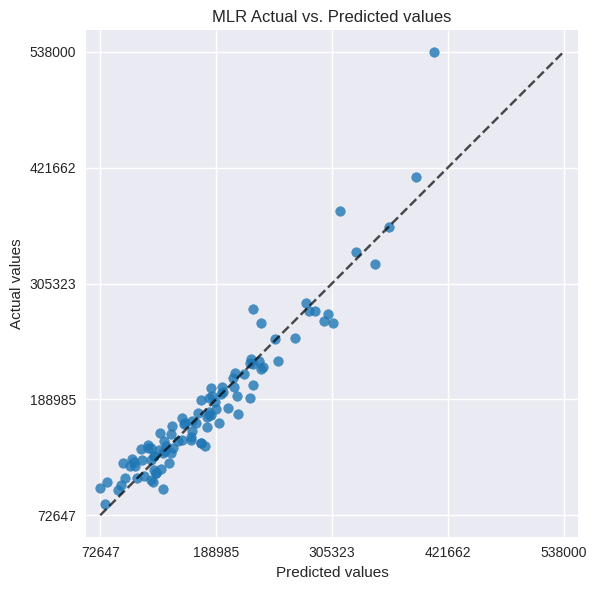

In [ ]:
# Plotting
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import PredictionErrorDisplay
import matplotlib.pyplot as plt

y_pred = cross_val_predict(lr, X, y, cv=kf)

sub = min(100, len(y))
fig, ax = plt.subplots(figsize=(6, 6))

PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=sub,
    ax=ax,
    random_state=42,
)

ax.set_title(f"MLR Actual vs. Predicted values")
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Feature contribution')

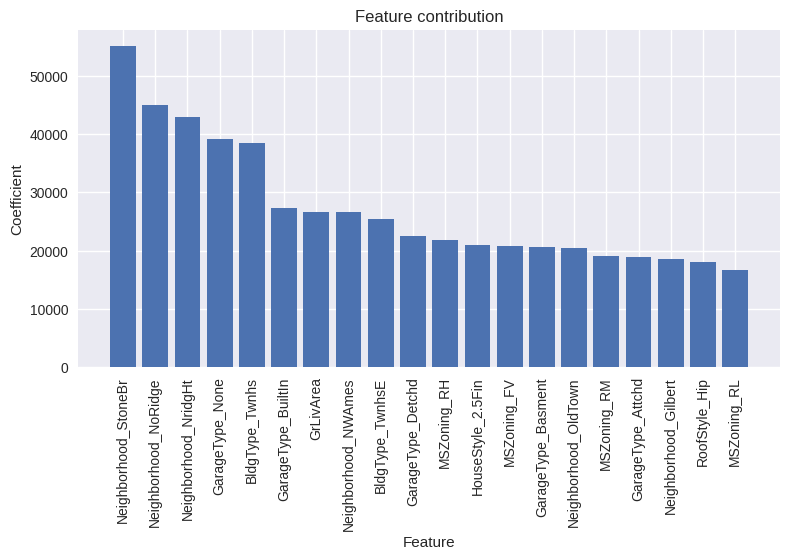

In [ ]:
# Feature contribution
lr.fit(X, y)

coef_df = pd.DataFrame({"Feature": X.columns, "Coefficient": lr.coef_})
coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()

sorted_df = coef_df[['Feature','Abs_Coefficient']].sort_values("Abs_Coefficient", ascending=False)

plt.bar(sorted_df['Feature'].head(20), sorted_df['Abs_Coefficient'].head(20))
plt.xlabel('Feature')
plt.xticks(rotation=90, ha="center")
plt.ylabel('Coefficient')
plt.tight_layout()
plt.title('Feature contribution')

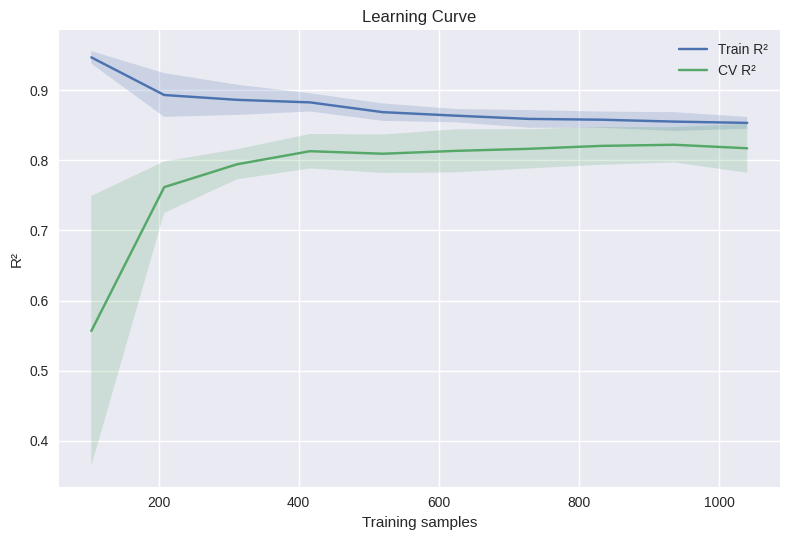

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    lr, X, y,
    cv=kf,
    scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1,
    shuffle=True,
    random_state=42
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)

test_mean = test_scores.mean(axis=1)
test_std  = test_scores.std(axis=1)

plt.plot(train_sizes, train_mean, label="Train R²")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, test_mean, label="CV R²")
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)

plt.xlabel("Training samples")
plt.ylabel("R²")
plt.legend()
plt.title("Learning Curve")
plt.tight_layout()
plt.show()


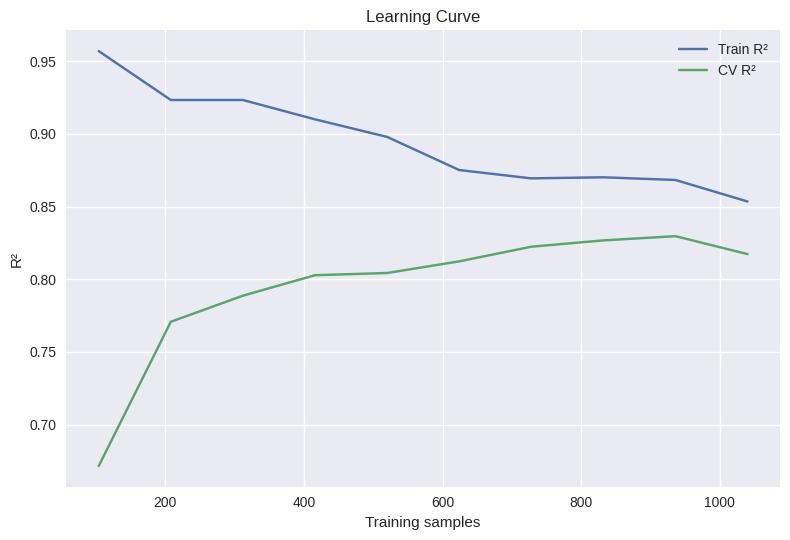

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    lr, X, y, cv=kf, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10)
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train R²")
plt.plot(train_sizes, test_scores.mean(axis=1), label="CV R²")
plt.xlabel("Training samples")
plt.ylabel("R²")
plt.legend()
plt.title("Learning Curve")
plt.tight_layout()
plt.show()

Random forest regression

In [ ]:
from sklearn.ensemble import RandomForestRegressor

k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

def adjusted_r2(estimator, X_fold, y_fold):
    y_pred = estimator.predict(X_fold)
    r2 = r2_score(y_fold, y_pred)
    n = X_fold.shape[0]
    p = X_fold.shape[1]
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

results = cross_validate(
    rf, X, y, cv=kf,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error",
        "adj_r2": adjusted_r2
    }
)

r2_scores = results["test_r2"]
rmse_scores = -results["test_rmse"]
adjr2_scores = results["test_adj_r2"]

print(f"R² Score for each fold:        {[round(s, 4) for s in r2_scores]}")
print(f"RMSE for each fold:            {[round(s, 2) for s in rmse_scores]}")
print(f"Adjusted R² for each fold:     {[round(s, 4) for s in adjr2_scores]}")

print(f"Average RMSE across {k} folds: {np.nanmean(rmse_scores):.2f}")
print(f"Average R² across {k} folds:   {np.nanmean(r2_scores):.4f}")
print(f"Average Adjusted R² across {k} folds: {np.nanmean(adjr2_scores):.4f}")

R² Score for each fold:        [np.float64(0.8903), np.float64(0.7642), np.float64(0.8809), np.float64(0.7792), np.float64(0.8751)]
RMSE for each fold:            [np.float64(28546.47), np.float64(36907.59), np.float64(26675.37), np.float64(41563.46), np.float64(25047.72)]
Adjusted R² for each fold:     [np.float64(0.8496), np.float64(0.6768), np.float64(0.8368), np.float64(0.6974), np.float64(0.8289)]
Average RMSE across 5 folds: 31748.12
Average R² across 5 folds:   0.8379
Average Adjusted R² across 5 folds: 0.7779


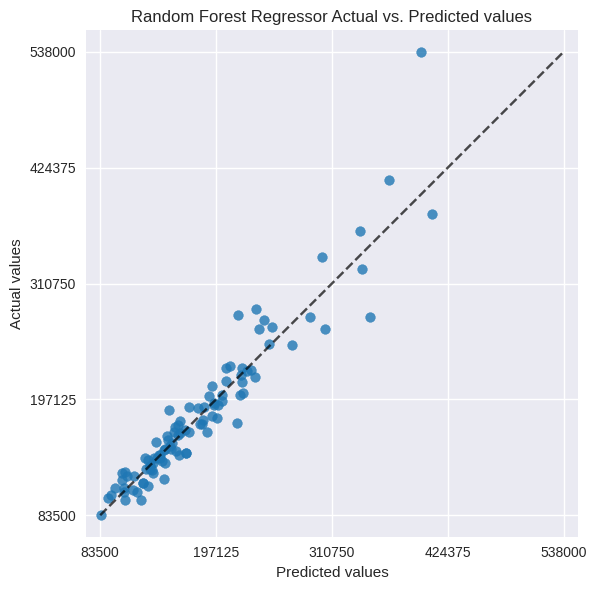

In [ ]:
# Plotting
y_pred = cross_val_predict(rf, X, y, cv=kf)

sub = min(100, len(y))
fig, ax = plt.subplots(figsize=(6, 6))

PredictionErrorDisplay.from_predictions(
    y,
    y_pred=y_pred,
    kind="actual_vs_predicted",
    subsample=sub,
    ax=ax,
    random_state=42,
)

ax.set_title(f"Random Forest Regressor Actual vs. Predicted values")
plt.tight_layout()
plt.show()

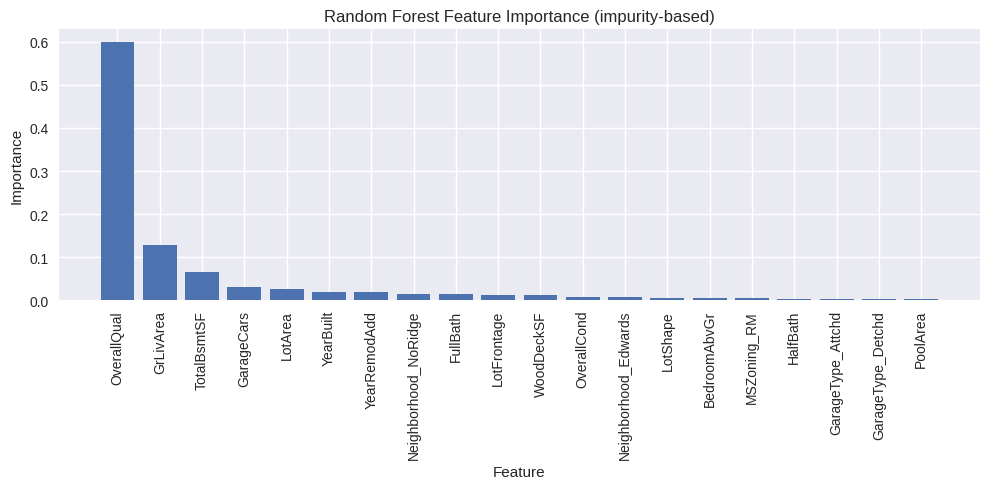

In [ ]:
# Feature importance (Random Forest)
rf.fit(X, y)

imp_df = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 5))
plt.bar(imp_df["Feature"].head(20), imp_df["Importance"].head(20))
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.xticks(rotation=90, ha="center")
plt.title("Random Forest Feature Importance (impurity-based)")
plt.tight_layout()
plt.show()

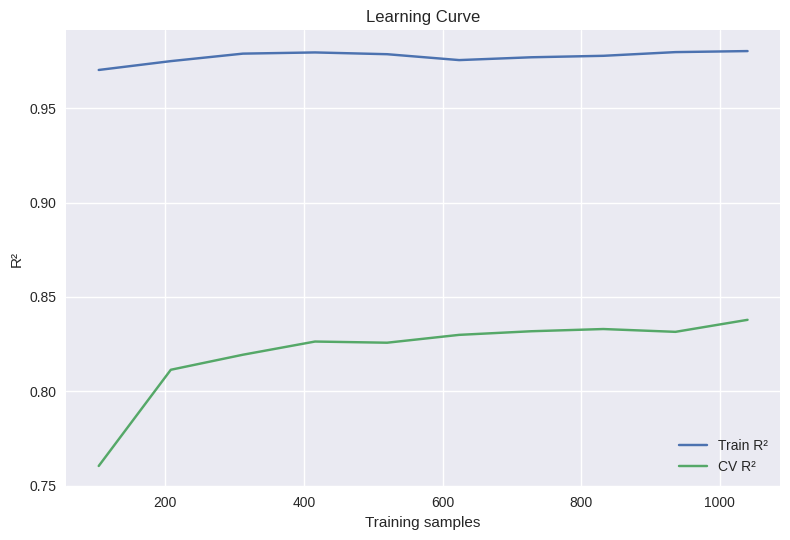

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    rf, X, y, cv=kf, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train R²")
plt.plot(train_sizes, test_scores.mean(axis=1), label="CV R²")
plt.xlabel("Training samples")
plt.ylabel("R²")
plt.legend()
plt.title("Learning Curve")
plt.tight_layout()
plt.show()

In [ ]:
# Tuning
rf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'criterion': 'squared_error',
 'max_depth': None,
 'max_features': 1.0,
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': -1,
 'oob_score': False,
 'random_state': 42,
 'verbose': 0,
 'warm_start': False}

In [ ]:
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score

param_dist = {
    "n_estimators": [800, 1200, 1600, 2000],
    "max_depth": [4, 6, 8, 10, 12],                 # avoid very deep trees
    "min_samples_split": [10, 20, 40, 80],
    "min_samples_leaf": [4, 8, 16, 24, 32],         # push leaves larger
    "max_features": ["sqrt", 0.15, 0.2, 0.3],        # fewer features per split
    "bootstrap": [True],
    "max_samples": [0.5, 0.6, 0.7, 0.8],            # stronger row subsampling
    "min_impurity_decrease": [0.0, 1e-4, 5e-4, 1e-3]
}

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "adj_r2": adjusted_r2
}

tune = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=50,
    cv=kf,
    scoring=scoring,
    refit="rmse", # The best model by rmse
    n_jobs=-1,
    verbose=1,
    random_state=42
)

tune.fit(X, y)

best_i = tune.best_index_
result = tune.cv_results_

best_rmse = -result["mean_test_rmse"][best_i]
best_r2 = result["mean_test_r2"][best_i]
best_adj_r2 = result["mean_test_adj_r2"][best_i]

print("Best params:", tune.best_params_)
print(f"CV RMSE (mean): {best_rmse:.2f}")
print(f"CV R²   (mean): {best_r2:.4f}")
print(f"CV Adj R²(mean): {best_adj_r2:.4f}")

best_rf = tune.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'n_estimators': 1600, 'min_samples_split': 10, 'min_samples_leaf': 4, 'min_impurity_decrease': 0.0, 'max_samples': 0.7, 'max_features': 0.2, 'max_depth': 6, 'bootstrap': True}
CV RMSE (mean): 33399.25
CV R²   (mean): 0.8245
CV Adj R²(mean): 0.7595


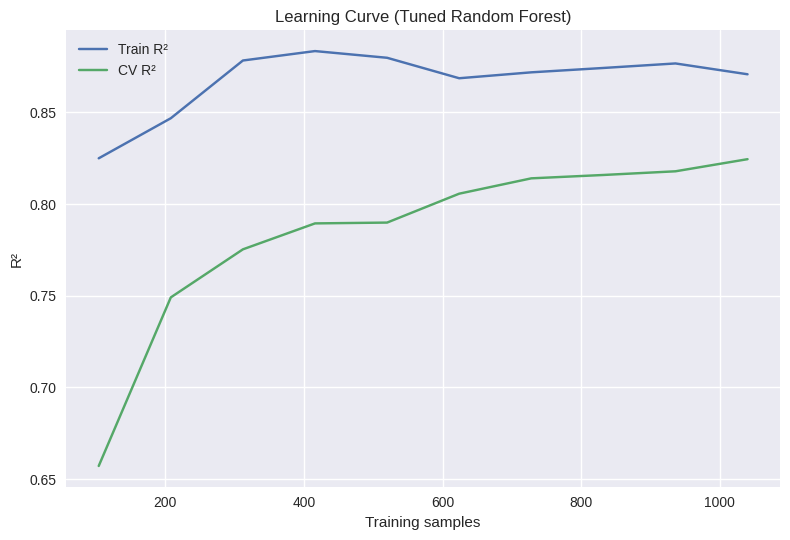

In [ ]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

train_sizes, train_scores, test_scores = learning_curve(
    tune.best_estimator_,  # or best_rf
    X, y, cv=kf, scoring="r2",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.plot(train_sizes, train_scores.mean(axis=1), label="Train R²")
plt.plot(train_sizes, test_scores.mean(axis=1), label="CV R²")
plt.xlabel("Training samples")
plt.ylabel("R²")
plt.legend()
plt.title("Learning Curve (Tuned Random Forest)")
plt.tight_layout()
plt.show()